**Zaimplementuj algorytm genetyczny z ANFIS**

Wymagania: 

- kodowanie binarne bądź dyskretne/ciągłe genotypu 
- parametryzacja długości genotypu, wielkości populacji 
- krzyżowanie k-punktowe z prawdopodobieństwem pk, losowanie locusów bez zwracania 
- mutacja m-punktowa z prawdopodobieństwem pm, losowanie locusów bez zwracania 
- selekcja: 
    - rankingowa: n najlepszych osobników zastępuje w populacji n najgorszych 
    - koło ruletki z uwzględnieniem funkcji transformującej wartości funkcji przystosowania 
- warunek stopu: liczba pokoleń, opcjonalnie docelowa wartość funkcji przystosowania, % najlepszych osobników w populacji 
Użyj algorytmu do optymalizacji ANFIS.

In [7]:
import numpy as np
import random
from scipy.optimize import minimize, basinhopping
from scipy.stats import variation
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations, combinations
import time
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from helps_and_enhancers import calculate_combinations, my_reshape
from operators import productN
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids

from goal_function_object import *


class AnfisWithGenetic:
    
    def __init__(self, inputs, training_data: np.ndarray, expected_labels: np.ndarray, operator_function=productN, operator_init_value=0.5):
        self.input_list = inputs
        self.input_number = len(inputs)
        self.training_data = training_data
        self.expected_labels = expected_labels
        
        self.premises = []
        for i in range(self.input_number):
            self.premises.append(self.input_list[i].get())

        self.nodes_number = np.prod([inp.n_functions for inp in self.input_list])
        
        self.operator_function=operator_function
        
        #self.tsk = np.ones((self.nodes_number ,self.input_number+1))
        self.tsk = np.random.random((self.nodes_number ,self.input_number+1))
        
        self.op  = [operator_init_value]*self.nodes_number

        self.calculate_aids()

    #Wyswietlanie funkcji przynależnosci
    def show_inputs(self):
        plt.figure()
        for i in range(self.input_number):
            plt.subplot(self.input_number, 1, i+1)
            self.input_list[i].show()
            plt.legend()
        plt.show()

    def set_premises_parameters(self, fv):
        fv = np.array(fv).reshape(np.shape(self.premises))
        self.premises=fv
        for i in range(self.input_number):
            self.input_list[i].set(*fv[i])
             
    def calculate_aids(self):
        self.premises_combinations = np.array(calculate_combinations(self))[:,::-1]

    def output_to_labels(self, y_pred):
        rounded = np.round(y_pred.flatten()).astype(int)
        r_shape = np.shape(rounded)
        return np.max((np.min((rounded , np.ones(r_shape)),axis=0), np.zeros(r_shape)),axis=0)#clamp 0-1       
               
    def anfis_estimate_labels(self, fv, op, tsk) -> np.ndarray:

        data = self.training_data

        self.set_premises_parameters(fv)
        tsk=np.reshape(tsk,np.shape(self.tsk))
        memberships = [self.input_list[x].fuzzify(data[x]) for x in range(self.input_number)]
        
        #Wnioskowanie
        arguments = []
        for premises in self.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:,premises[i]])
            arguments.append(   item  )

        arguments = np.transpose(arguments, (1,2,0))
        
        R=self.operator_function(arguments, op)
        
        #Normalizacja normalizacja poziomów aktywacji reguł
        Rsum = np.sum(R, axis=1, keepdims=True)

        Rnorm = R / Rsum
        Rnorm[(Rsum==0).flatten(),:] = 0
        # wylicz wartoci przesłanek dla każdej próbki
        
        dataXYZ1 = np.vstack((self.training_data,np.ones(len(self.training_data[0])))).T
        Q = np.dot(dataXYZ1, tsk.T) 
        
        # wyznacz wyniki wnioskowania dla każdej próbki
        result = (Q * Rnorm).sum(axis=1, keepdims=True)
    
        return result.T    
        
    def show_results(self, color=None):
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        if color is None:
            color = [[1,0,0] if cc else [0,1,0] for cc in self.expected_labels]

        result = self.anfis_estimate_labels(self.premises,self.op,self.tsk)
        
        #ax.scatter(np.array(self.training_data)[:,0], np.array(self.training_data)[:,1], result, c=rgb)
        ax.scatter(self.training_data[0], self.training_data[1], result, c=color)
        
        plt.show()
    
    def set_training_and_testing_data(self, training_data, expected_labels):
        self.training_data = training_data
        self.expected_labels = expected_labels
        
    def train(self, global_optimization: bool, learn_premises: bool, learn_operators: bool, learn_consequents: bool, n_iter=100, bounds_premises=None):
        
        x1 = [ item for sublist in self.premises for item in sublist ]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
          
        if bounds_premises is None:
            bfv = [(0,4)]*len(x1)
        else:
            bfv = bounds_premises
        bop  = [(0.0,2.0)]*len(x2)
        btsk = [(0,2)]*len(x3)
        
        niter_success=100
            
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1,x2,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1,x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]

        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter)#, niter_success=niter_success)
            else:
                res = minimize(goal_premises_consequents, x0, method='SLSQP', bounds=bounds, args=self, tol=1e-6)

            self.set_premises_parameters(res.x[:self.end_x1]) ##zmiana funkcji
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))

        elif learn_operators and learn_consequents:
            print("4")
            x0 = np.hstack((x2,x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
        
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))

        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[:]
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            
            bounds = btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self), "tol":1e-03}
                res = basinhopping(goal_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.tsk=res.x[:].reshape(np.shape(self.tsk))
            
        else:
            print("Error")
            assert(0)
            
        print("Optymalizacja zakończona!")
        print("z blędem:  ", res.fun)
        print("Liczba ew: ", res.nfev)
        print("Liczba it: ", res.nit)

    def train_genetic(self, learn_premises=True, learn_operators=True, learn_consequents=True,
                  pop_size=50, generations=200, pk=0.9, k_points=2, pm=0.2, m_points=2,
                  mutation_strength=0.05, selection='roulette', convergence_pct=0.95,
                  convergence_tol=1e-4, target_fitness=None, verbose=True):
  
        x1 = np.array([v for sub in self.premises for v in sub]).flatten()
        x2 = np.array(self.op).flatten()
        x3 = np.array(self.tsk).flatten()

        bounds, genes = [], []
        if learn_premises:
            bounds += [(0, 4)] * len(x1)
            genes.append(x1)
        if learn_operators:
            bounds += [(0, 2)] * len(x2)
            genes.append(x2)
        if learn_consequents:
            bounds += [(0, 2)] * len(x3)
            genes.append(x3)

        genotype_len = sum(len(g) for g in genes)
        bounds = np.array(bounds)

        def fitness(ind):
            idx = 0
            if learn_premises:
                self.set_premises_parameters(ind[idx:idx + len(x1)].reshape(np.shape(self.premises)))
                idx += len(x1)
            if learn_operators:
                self.op = ind[idx:idx + len(x2)]
                idx += len(x2)
            if learn_consequents:
                self.tsk = ind[idx:idx + len(x3)].reshape(np.shape(self.tsk))

            y_pred = self.anfis_estimate_labels(self.premises, self.op, self.tsk).flatten()
            return np.mean((self.expected_labels - y_pred) ** 2)

        def select_parents(pop, fits):
            if selection == 'ranking':
                ranked = pop[np.argsort(fits)]
                return ranked[:pop_size // 2]
            else:
                inv = 1 / (fits + 1e-9)
                probs = inv / np.sum(inv)
                idx = np.random.choice(len(pop), size=pop_size // 2, p=probs)
                return pop[idx]

        def crossover(p1, p2):
            if np.random.rand() > pk:
                return p1.copy(), p2.copy()
            points = sorted(np.random.choice(range(1, genotype_len), k_points, replace=False))
            c1, c2 = p1.copy(), p2.copy()
            for i, (start, end) in enumerate(zip([0]+points, points+[genotype_len])):
                if i % 2 == 1:
                    c1[start:end], c2[start:end] = c2[start:end], c1[start:end]
            return c1, c2

        def mutate(ind):
            if np.random.rand() > pm:
                return ind
            loci = np.random.choice(genotype_len, m_points, replace=False)
            for locus in loci:
                low, high = bounds[locus]
                delta = np.random.uniform(-mutation_strength, mutation_strength)
                ind[locus] = np.clip(ind[locus] + delta, low, high)
            return ind

        pop = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(pop_size, genotype_len))
        fits = np.array([fitness(ind) for ind in pop])
        best_idx = np.argmin(fits)
        best_ind, best_fit = pop[best_idx].copy(), fits[best_idx]

        if verbose:
            print(f"Start GA: najlepszy fitness = {best_fit:.6f}")

        for gen in range(generations):
            parents = select_parents(pop, fits)

            offspring = []
            while len(offspring) < pop_size:
                p1, p2 = parents[np.random.randint(len(parents), size=2)]
                c1, c2 = crossover(p1, p2)
                offspring.extend([mutate(c1), mutate(c2)])
            offspring = np.array(offspring[:pop_size])

            off_fits = np.array([fitness(ind) for ind in offspring])

            combined = np.vstack([pop, offspring])
            combined_fits = np.hstack([fits, off_fits])
            idx = np.argsort(combined_fits)
            pop, fits = combined[idx[:pop_size]], combined_fits[idx[:pop_size]]

            if fits[0] < best_fit:
                best_fit = fits[0]
                best_ind = pop[0].copy()

            if target_fitness and best_fit <= target_fitness:
                if verbose: print(f"🎯 Osiągnięto cel w generacji {gen}")
                break

            sorted_fits = np.sort(fits)
            top = int(convergence_pct * pop_size)
            if np.std(sorted_fits[:top]) < convergence_tol:
                if verbose: print(f"⚙️ Zbieżność {convergence_pct*100:.1f}% populacji w gen. {gen}")
                break

            if verbose and gen % 10 == 0:
                print(f"Pokolenie {gen}: najlepszy fitness = {best_fit:.6f}")

        idx = 0
        if learn_premises:
            self.set_premises_parameters(best_ind[idx:idx + len(x1)].reshape(np.shape(self.premises)))
            idx += len(x1)
        if learn_operators:
            self.op = best_ind[idx:idx + len(x2)]
            idx += len(x2)
        if learn_consequents:
            self.tsk = best_ind[idx:idx + len(x3)].reshape(np.shape(self.tsk))

        print("\n✅ Trening genetyczny zakończony!")
        print(f"Najlepszy fitness (MSE): {best_fit:.6f}")
        return best_ind, best_fit

    

**Sprawdzenie genetycznego** 

Tabliczka: 2x2


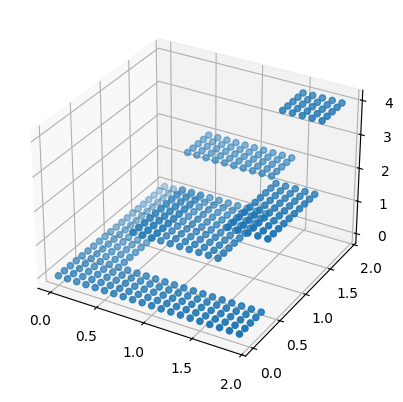

Start GA: najlepszy fitness = 0.496895
Pokolenie 0: najlepszy fitness = 0.496895
Pokolenie 10: najlepszy fitness = 0.388609
Pokolenie 20: najlepszy fitness = 0.367859


C:\Users\Filip\AppData\Local\Temp\ipykernel_15520\4117874306.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Pokolenie 30: najlepszy fitness = 0.366939
⚙️ Zbieżność 95.0% populacji w gen. 33

✅ Trening genetyczny zakończony!
Najlepszy fitness (MSE): 0.366939


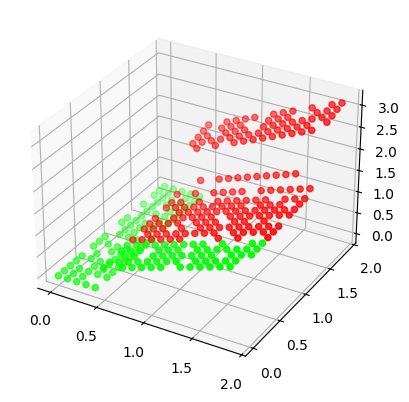

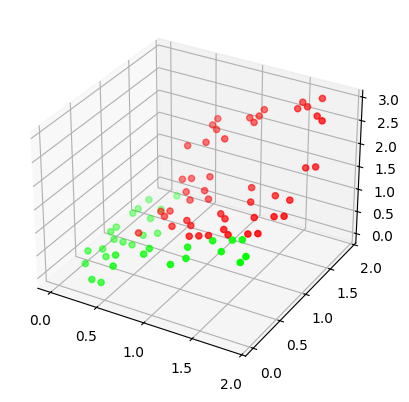

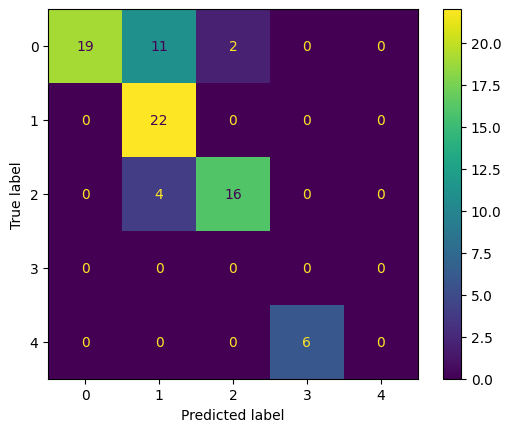

Tabliczka: 3x3


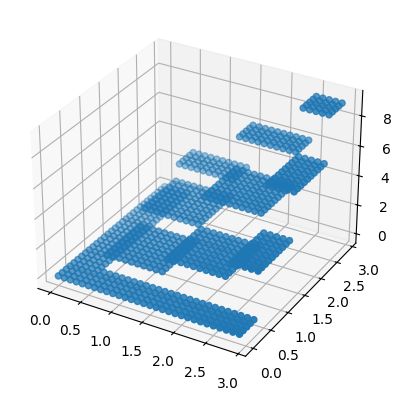

Start GA: najlepszy fitness = 2.000883
Pokolenie 0: najlepszy fitness = 1.993688
Pokolenie 10: najlepszy fitness = 1.453421


C:\Users\Filip\AppData\Local\Temp\ipykernel_15520\4117874306.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Pokolenie 20: najlepszy fitness = 1.446284
Pokolenie 30: najlepszy fitness = 1.435173
Pokolenie 40: najlepszy fitness = 1.427125

✅ Trening genetyczny zakończony!
Najlepszy fitness (MSE): 1.422407


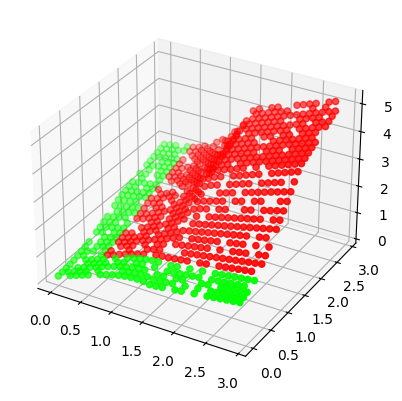

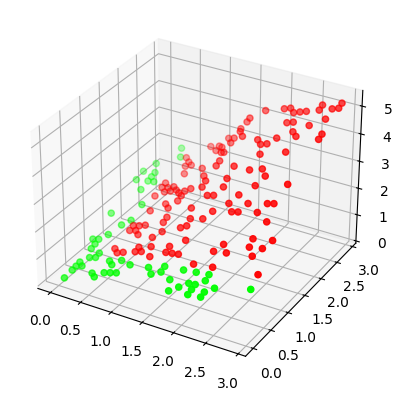

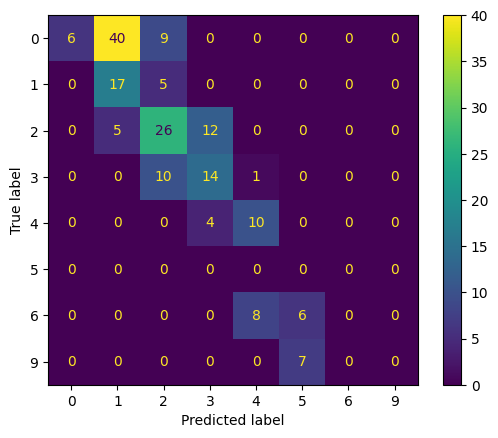

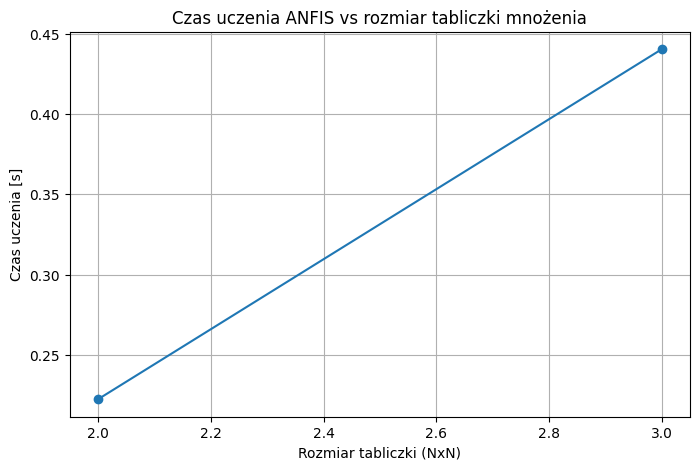

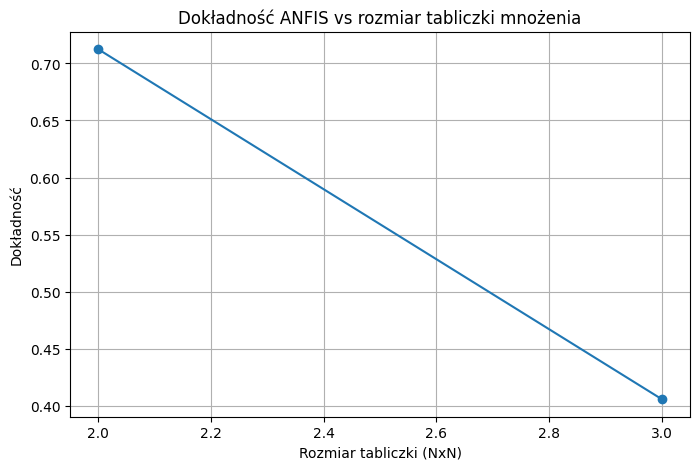

In [8]:
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sizes = [2, 3]
times = []
accuracies = []

def custom_round(val):
    return int(val + 0.5)

for size in sizes:
    print(f"Tabliczka: {size}x{size}")

    x = np.arange(0, size, 0.1)
    x,y = np.meshgrid(x, x)

    dataX = x.flatten()
    dataY = y.flatten()
    dataXY = np.column_stack((dataX,dataY))   

    data_labels = [custom_round(a) * custom_round(b) for a, b in dataXY]

    # for x in range(len(dataXY)):
    #     print(x, dataXY[x], data_labels[x])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(dataX, dataY, data_labels)
    plt.show()

    # varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) 
    # varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

    mf1 = [[-0.5, 0.25, 0.25, 0.25], [0.5, 0.25, 0.1, 0.1]]
    varX = FuzzyInputVariable_List_Trapezoids(mf1, "XAxis", ["L","H"])
    varY = FuzzyInputVariable_List_Trapezoids(mf1, "YAxis", ["L","H"])

    X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

    fis = AnfisWithGenetic([varX, varY], X_train.T, y_train)

    start = time.time()
    fis.train_genetic(learn_premises=True, learn_operators=True, learn_consequents=False, generations=50)
    end = time.time()
    times.append(end-start)
    fis.training_data = X_train.T
    fis.expected_labels = y_train
    fis.show_results()

    fis.training_data = X_test.T
    fis.expected_labels = y_test
    fis.show_results()

    y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
    y_pred = list(map(round,y_pred.flatten()))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(sizes, times, marker='o')
plt.xlabel('Rozmiar tabliczki (NxN)')
plt.ylabel('Czas uczenia [s]')
plt.title('Czas uczenia ANFIS vs rozmiar tabliczki mnożenia')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(sizes, accuracies, marker='o')
plt.xlabel('Rozmiar tabliczki (NxN)')
plt.ylabel('Dokładność')
plt.title('Dokładność ANFIS vs rozmiar tabliczki mnożenia')
plt.grid(True)
plt.show()